# YOLO-Pose Inference for Vessel Detection

This notebook demonstrates how to run inference with a trained YOLO-Pose model on RC (Range-Compressed) SAR patches for vessel detection.

**Pipeline overview:**
1. Load model weights and configuration
2. Load a test image (PNG or TIFF)
3. Load ground-truth labels (YOLO-pose format)
4. Run inference and extract predictions
5. Visualise results: Ground Truth vs Predictions with confidence scores

## 1. Imports & Setup

We import the YOLO model from Ultralytics, image handling utilities, and our project helpers for reading config, loading labels, and profiling.

In [1]:
import os
import re
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from ultralytics import YOLO

try:
    import tifffile
    HAS_TIFFFILE = True
except ImportError:
    HAS_TIFFFILE = False

# --- Model selection: large or small ---
model_choice = input("Select model: 1 (large) or 2 (small): ").strip().lower()
if model_choice in ('2', 'small'):
    PROJECT_ROOT = Path('/app/small_model')
    config_path = PROJECT_ROOT / 'config.yaml'
else:
    PROJECT_ROOT = Path('/app/large_model')
    config_path = PROJECT_ROOT / 'config.yaml'

sys.path.insert(0, str(PROJECT_ROOT))

from utilities.read_yaml import read_yaml
from scripts.profile_model import profile_model

print(f"Project root: {PROJECT_ROOT}")
print(f"Config path: {config_path}")

Project root: /app/large_model
Config path: /app/large_model/config.yaml


## 2. Load Configuration

All paths and thresholds are defined in `config.yaml`. The inference section specifies:
- **model_path**: path to trained `.pt` weights
- **test_images_dir / test_labels_dir**: YOLO dataset test split
- **conf_threshold**: minimum confidence to keep a prediction
- **iou_threshold**: IoU threshold for NMS (suppresses duplicate boxes)

In [2]:
config = read_yaml(PROJECT_ROOT / 'config.yaml')
inf = config['inference']

MODEL_PATH      = inf['model_path']
TEST_IMAGES_DIR = inf['test_images_dir']
TEST_LABELS_DIR = inf['test_labels_dir']
CONF_THRESHOLD  = inf.get('conf_threshold', 0.001)
IOU_THRESHOLD   = inf.get('iou_threshold', 0.5)
IMGSZ           = inf.get('imgsz', 640)

print(f"Model:      {MODEL_PATH}")
print(f"Images dir: {TEST_IMAGES_DIR}")
print(f"Labels dir: {TEST_LABELS_DIR}")
print(f"Conf: {CONF_THRESHOLD}  |  IoU: {IOU_THRESHOLD}  |  ImgSz: {IMGSZ}")

Model:      /media/raid/opensar/yolo_results/runs/pose/pose/yolo26s-pose_opensar_true_vessel_filtered_dataset_640px/weights/best.pt
Images dir: /media/raid/opensar/yolo_dataset_true_vessels_filtered/images/test
Labels dir: /media/raid/opensar/yolo_dataset_true_vessels_filtered/labels/test
Conf: 0.3  |  IoU: 0.5  |  ImgSz: 640


## 3. Load Model

Load the YOLO-Pose model and move it to GPU. We also profile the model to get FLOPs, parameter count, and latency estimates.

In [3]:
model = YOLO(MODEL_PATH)

import torch
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model.model.to(device)
print(f"Device: {device}")

# Profile model (GFLOPs, params, latency)
profile_stats = profile_model(model, imgsz=IMGSZ)
print(f"\nGFLOPs: {profile_stats.get('profile/GFLOPs', 0):.2f}")
print(f"Params: {profile_stats.get('profile/params_M', 0):.2f} M")
print(f"Latency: {profile_stats.get('profile/latency_ms', 0):.1f} ms")
print(f"FPS: {profile_stats.get('profile/fps', 0):.1f}")

Device: cuda:0

════════════════════════════════════════════════════════════
  Model Profile
════════════════════════════════════════════════════════════

  > Complexity
  ──────────────────────────────────────────────────────────
  GMACs                            12.236  GMACs
  GFLOPs                           24.472  GFLOPs
  params_M                         10.521  M params

  > Latency
  ──────────────────────────────────────────────────────────
  latency_ms                       12.520  ms
  fps                              79.875  FPS

  > GPU Memory
  ──────────────────────────────────────────────────────────
  gpu_mem_alloc_GB                  0.081  GB
  gpu_mem_peak_GB                   0.134  GB

  > GPU Compute
  ──────────────────────────────────────────────────────────
  gpu_util_avg_%                   32.800  %
  gpu_util_peak_%                  40.000  %

  > GPU Power
  ──────────────────────────────────────────────────────────
  gpu_power_avg_W                 146.

## 4. Helper Functions

These functions handle:
- **Image loading**: supports both PNG and multi-channel TIFF formats
- **Label parsing**: reads YOLO-pose format (`class xc yc w h kp_x kp_y kp_vis`) and converts to pixel coordinates
- **Prediction extraction**: pulls bounding boxes, keypoints, and confidence scores from YOLO results
- **Visualisation**: draws bounding boxes, keypoints, and confidence labels on axes

In [4]:
# ── Visual style ──
GT_COLOR   = '#FF3333'   # red for ground truth
PRED_COLOR = '#33FF33'   # lime for predictions
KP_SIZE    = 60
BOX_LW     = 1.5
PANEL_BG   = '#1e1e1e'
PANEL_FG   = '#e0e0e0'


def load_rc_image(img_path: str):
    """Load a PNG or TIFF image and return (rgb_array, height, width)."""
    ext = Path(img_path).suffix.lower()
    if ext in ('.tif', '.tiff'):
        if not HAS_TIFFFILE:
            raise ImportError('tifffile not installed')
        arr = tifffile.imread(img_path)
        display = arr[3] if arr.ndim == 3 and arr.shape[0] == 4 else arr[0]
        rgb = np.stack([display, display, display], axis=-1)
    else:
        rgb = np.array(Image.open(img_path).convert('RGB'))
    return rgb, rgb.shape[0], rgb.shape[1]


def load_pose_labels(label_path, img_w, img_h):
    """Load YOLO-pose label file and return list of dicts with 'bbox' and 'kp' in pixels."""
    entries = []
    if not os.path.exists(label_path):
        return entries
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            x_c, y_c, w, h = map(float, parts[1:5])
            x1 = (x_c - w / 2) * img_w
            y1 = (y_c - h / 2) * img_h
            x2 = (x_c + w / 2) * img_w
            y2 = (y_c + h / 2) * img_h
            kp = None
            if len(parts) >= 8:
                kp = (float(parts[5]) * img_w, float(parts[6]) * img_h)
            else:
                kp = (x_c * img_w, y_c * img_h)
            entries.append({'bbox': [x1, y1, x2, y2], 'kp': kp})
    return entries


def extract_pose_predictions(results, conf_threshold=0.0):
    """Extract bbox, keypoint, and confidence from YOLO-pose results."""
    entries = []
    r = results[0]
    if r.boxes is None or len(r.boxes) == 0:
        return entries
    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    kps = None
    if r.keypoints is not None and r.keypoints.data is not None:
        kps = r.keypoints.data.cpu().numpy()
    for i in range(len(boxes)):
        if confs[i] < conf_threshold:
            continue
        x1, y1, x2, y2 = boxes[i]
        kp = None
        if kps is not None and i < len(kps):
            kp = (float(kps[i][0][0]), float(kps[i][0][1]))
        entries.append({
            'bbox': [float(x1), float(y1), float(x2), float(y2)],
            'kp': kp,
            'conf': float(confs[i]),
        })
    return entries


def draw_boxes_and_kps(ax, entries, box_color, kp_color, label, show_conf=False):
    """Draw bounding boxes with optional confidence labels and keypoint markers."""
    for i, entry in enumerate(entries):
        x1, y1, x2, y2 = entry['bbox']
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=BOX_LW, edgecolor=box_color,
            facecolor='none', linestyle='--',
            label=f'{label} box' if i == 0 else None
        )
        ax.add_patch(rect)
        if show_conf and 'conf' in entry:
            ax.text(x1, y1 - 2, f'{entry["conf"]:.2f}',
                    color=box_color, fontsize=7, fontweight='bold',
                    verticalalignment='bottom',
                    bbox=dict(facecolor='black', alpha=0.6, pad=1, edgecolor='none'))
        if entry['kp'] is not None:
            kx, ky = entry['kp']
            ax.scatter(kx, ky, c=kp_color, s=KP_SIZE, marker='x',
                       linewidths=2, zorder=5,
                       label=f'{label} kp' if i == 0 else None)

print('Helpers loaded.')

Helpers loaded.


## 5. List Available Test Images

Scan the test images directory and display the first few filenames. Each image follows the naming convention `DB_OPENSAR_{POL}_VD_{PATCH_ID}.png`.

In [5]:
test_images = sorted([
    f for f in os.listdir(TEST_IMAGES_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
])
print(f"Found {len(test_images)} test images")
print("\nFirst 10:")
for img in test_images[:10]:
    print(f"  {img}")

Found 199 test images

First 10:
  DB_OPENSAR_VH_VD_104.png
  DB_OPENSAR_VH_VD_11.png
  DB_OPENSAR_VH_VD_114.png
  DB_OPENSAR_VH_VD_117.png
  DB_OPENSAR_VH_VD_122.png
  DB_OPENSAR_VH_VD_126.png
  DB_OPENSAR_VH_VD_134.png
  DB_OPENSAR_VH_VD_138.png
  DB_OPENSAR_VH_VD_14.png
  DB_OPENSAR_VH_VD_15.png


## 6. Run Inference on a Single Image

Select one image, load it, run inference, and compare ground truth vs predictions.

Change `IMAGE_INDEX` below to try different images.

In [6]:
# ── Select image ──
IMAGE_INDEX = 0  # Change this to pick a different test image

img_name   = test_images[IMAGE_INDEX]
img_path   = os.path.join(TEST_IMAGES_DIR, img_name)
label_path = os.path.join(TEST_LABELS_DIR, Path(img_name).stem + '.txt')

# Extract metadata from filename
patch_num = re.search(r'VD_(\d+)', img_name)
patch_num = patch_num.group(1) if patch_num else 'unknown'
pol = 'VH' if '_VH_' in img_name else ('VV' if '_VV_' in img_name else 'unknown')

print(f"Image: {img_name}")
print(f"Patch: VD_{patch_num}  |  Polarization: {pol}")

Image: DB_OPENSAR_VH_VD_104.png
Patch: VD_104  |  Polarization: VH


In [7]:
# ── Load image and ground truth ──
img_array, rc_h, rc_w = load_rc_image(img_path)
gt_entries = load_pose_labels(label_path, rc_w, rc_h)

print(f"Image size: {rc_w} x {rc_h}")
print(f"Ground truth objects: {len(gt_entries)}")

Image size: 512 x 633
Ground truth objects: 5


In [8]:
# ── Run timed inference ──
t0 = time.perf_counter()
results = model.predict(
    img_path,
    imgsz=IMGSZ,
    iou=IOU_THRESHOLD,
    conf=CONF_THRESHOLD,
    verbose=False
)
infer_ms = (time.perf_counter() - t0) * 1000

pred_entries = extract_pose_predictions(results, CONF_THRESHOLD)

print(f"Predictions: {len(pred_entries)}")
print(f"Inference latency: {infer_ms:.1f} ms")
if pred_entries:
    confs = [e['conf'] for e in pred_entries]
    print(f"Confidence range: {min(confs):.4f} — {max(confs):.4f}")

Predictions: 2
Inference latency: 258.9 ms
Confidence range: 0.5784 — 0.6834


## 7. Visualise: Ground Truth vs Predictions

Side-by-side comparison:
- **Left**: RC patch with ground-truth bounding boxes (red) and keypoints
- **Right**: RC patch with predicted bounding boxes (green), keypoints, and confidence scores

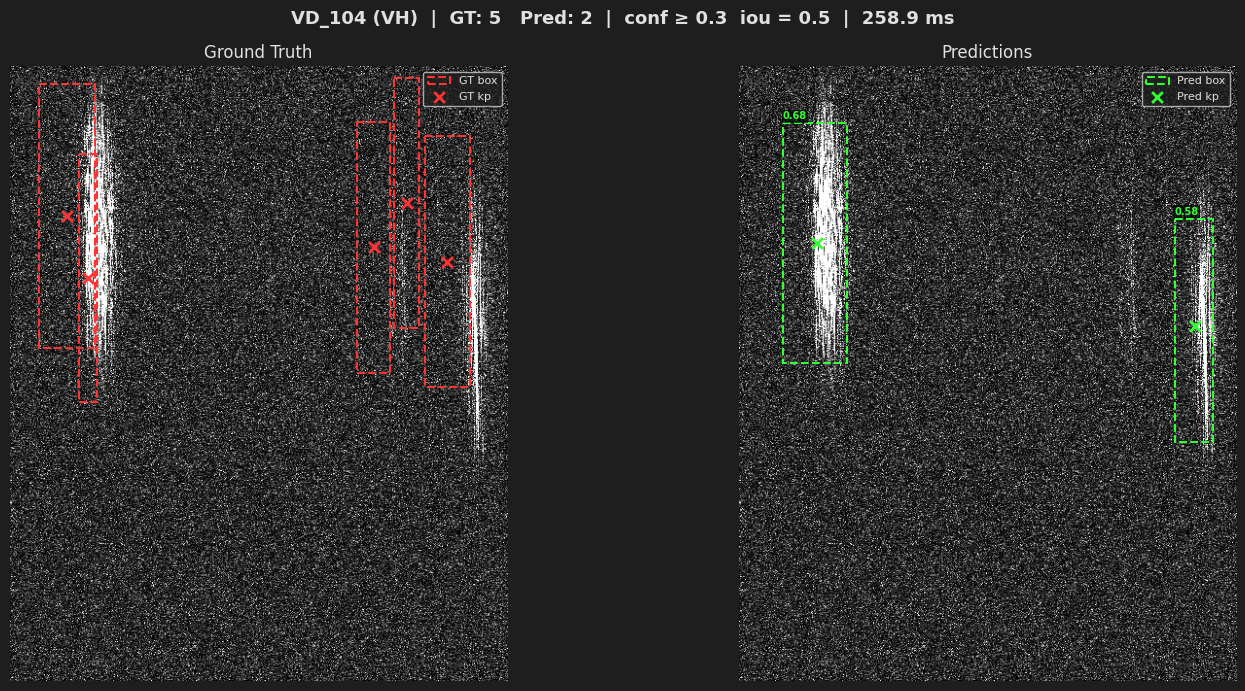

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(PANEL_BG)
fig.suptitle(
    f'VD_{patch_num} ({pol})  |  GT: {len(gt_entries)}   Pred: {len(pred_entries)}  |  '
    f'conf ≥ {CONF_THRESHOLD}  iou = {IOU_THRESHOLD}  |  {infer_ms:.1f} ms',
    fontsize=13, fontweight='bold', color=PANEL_FG
)

# ── Panel 1: Ground Truth ──
axes[0].set_facecolor('#111111')
axes[0].imshow(img_array, cmap='gray' if img_array.ndim == 2 else None)
axes[0].set_title('Ground Truth', fontsize=12, color=PANEL_FG)
draw_boxes_and_kps(axes[0], gt_entries, GT_COLOR, GT_COLOR, 'GT')
if gt_entries:
    leg = axes[0].legend(loc='upper right', fontsize=8)
    leg.get_frame().set_facecolor(PANEL_BG)
    for t in leg.get_texts(): t.set_color(PANEL_FG)
axes[0].axis('off')

# ── Panel 2: Predictions (with confidence scores) ──
axes[1].set_facecolor('#111111')
axes[1].imshow(img_array, cmap='gray' if img_array.ndim == 2 else None)
axes[1].set_title('Predictions', fontsize=12, color=PANEL_FG)
draw_boxes_and_kps(axes[1], pred_entries, PRED_COLOR, PRED_COLOR, 'Pred', show_conf=True)
if pred_entries:
    leg = axes[1].legend(loc='upper right', fontsize=8)
    leg.get_frame().set_facecolor(PANEL_BG)
    for t in leg.get_texts(): t.set_color(PANEL_FG)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 8. Batch Inference on Multiple Images

Run inference on a batch of images and collect per-image statistics (latency, number of detections, confidence scores).

Adjust `NUM_IMAGES` to control how many images to process.

In [10]:
NUM_IMAGES = min(5, len(test_images))  # Process up to 20 images

batch_results = []
for img_name in test_images[:NUM_IMAGES]:
    img_path   = os.path.join(TEST_IMAGES_DIR, img_name)
    label_path = os.path.join(TEST_LABELS_DIR, Path(img_name).stem + '.txt')

    img_array, rc_h, rc_w = load_rc_image(img_path)
    gt = load_pose_labels(label_path, rc_w, rc_h)

    t0 = time.perf_counter()
    results = model.predict(img_path, imgsz=IMGSZ, iou=IOU_THRESHOLD, conf=CONF_THRESHOLD, verbose=False)
    latency = (time.perf_counter() - t0) * 1000

    preds = extract_pose_predictions(results, CONF_THRESHOLD)
    confs = [e['conf'] for e in preds]

    batch_results.append({
        'image': img_name,
        'gt_count': len(gt),
        'pred_count': len(preds),
        'latency_ms': latency,
        'max_conf': max(confs) if confs else 0.0,
        'min_conf': min(confs) if confs else 0.0,
    })

# Display summary table
print(f"{'Image':<40} {'GT':>4} {'Pred':>5} {'Latency':>9} {'MaxConf':>8} {'MinConf':>8}")
print('-' * 80)
for r in batch_results:
    print(f"{r['image']:<40} {r['gt_count']:>4} {r['pred_count']:>5} {r['latency_ms']:>8.1f}ms {r['max_conf']:>8.4f} {r['min_conf']:>8.4f}")

avg_latency = np.mean([r['latency_ms'] for r in batch_results])
print(f"\nAverage latency: {avg_latency:.1f} ms  |  FPS: {1000/avg_latency:.1f}")

Image                                      GT  Pred   Latency  MaxConf  MinConf
--------------------------------------------------------------------------------
DB_OPENSAR_VH_VD_104.png                    5     2     45.7ms   0.6834   0.5784
DB_OPENSAR_VH_VD_11.png                     2     1     35.6ms   0.7394   0.7394
DB_OPENSAR_VH_VD_114.png                    1     0     94.2ms   0.0000   0.0000
DB_OPENSAR_VH_VD_117.png                    1     0     38.1ms   0.0000   0.0000
DB_OPENSAR_VH_VD_122.png                    2     0     85.1ms   0.0000   0.0000

Average latency: 59.7 ms  |  FPS: 16.7
